In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# --- Funções de Processamento de Dados (Mantidas) ---

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of dictionaries, each containing (f, t, Zxx) for an epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            # print(f"        Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Ensure epoch is long enough for the STFT window
        if len(epoch) < nperseg:
            # print(f"        Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# --- Configurações Globais ---

# Pasta raiz contendo todas as subpastas de sujeitos (S001, S002, ...)
# Exemplo: Se seus arquivos estão em 'seu_projeto/data/phisionet_data/S001/'
# E o script está em 'seu_projeto/'
pasta_raiz_sujeitos = Path('data/phisionet_data') # <-- AJUSTE ISSO PARA O SEU CAMINHO RAIZ DOS SUJEITOS

# Define o range de sujeitos S001 a S109
# Ajuste 'start_subject' e 'end_subject' conforme sua necessidade (ex: de S001 a S030)
start_subject = 1
end_subject = 50 # Ou 30, ou qualquer outro número até 109

registros = ['R04', 'R08', 'R12'] # Arquivos EDF a serem processados por sujeito
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Mapeamento para nomes de pastas em minúsculas
epoch_duration_sec = 4 # Duração de cada época em segundos (tmax - tmin)

# Definir a taxa de amostragem globalmente (ASSUMIR UM VALOR CONSISTENTE OU LER DO PRIMEIRO ARQUIVO)
fs = 160 # Hz - Ajuste para a taxa de amostragem real dos seus dados

# Definir as durações de janela da STFT a serem testadas (em milissegundos)
window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]

print(f"Iniciando a geração de spectrograms para sujeitos S{start_subject:03d} a S{end_subject:03d}")
print(f"e para as janelas: {window_durations_ms}ms")

# --- Loop Principal para Processamento (Aninhado) ---

# Loop externo: sobre cada duração de janela da STFT
for current_window_ms in window_durations_ms:
    current_window_s = current_window_ms / 1000.0
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * current_window_s)
    noverlap = int(nperseg * 0.75) # 75% de sobreposição para boa resolução temporal
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1 e noverlap < nperseg
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)
    if nperseg == 1:
        noverlap = 0

    print(f"\n--- Processando com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    # Diretório de saída final para o dataset unificado para esta janela específica
    base_output_data_dir = f"unified_spectrograms_{current_window_ms}ms"
    
    # Crie as pastas de classe dentro do diretório de saída para esta janela
    for class_folder_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, class_folder_name), exist_ok=True)
    print(f"Diretório de saída para o dataset unificado: {base_output_data_dir}")

    # Loop intermediário: sobre cada sujeito no range especificado
    for subject_num in range(start_subject, end_subject + 1):
        subject_id = f'S{subject_num:03d}' # Formata para S001, S002, etc.
        subject_folder_path = pasta_raiz_sujeitos / subject_id

        if not subject_folder_path.is_dir():
            print(f"  Pasta do sujeito {subject_id} não encontrada em {pasta_raiz_sujeitos}. Pulando.")
            continue

        print(f"  Processando Sujeito: {subject_id}")

        # Loop interno: sobre cada arquivo EDF (R04, R08, R12) dentro do sujeito
        for registro in registros:
            # Encontrar arquivo .edf correspondente
            edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
            if not edf_file:
                print(f"    Arquivo {registro}.edf não encontrado em {subject_folder_path}. Pulando.")
                continue

            # print(f"      Processando arquivo: {edf_file.name}") # Descomente para mais detalhes
            
            # Carregar dados EDF usando EdfReader
            reader = EdfReader(str(edf_file))
            
            # Obter informações dos sinais e taxa de amostragem (use a global 'fs' ou leia por arquivo)
            # Se sua taxa de amostragem varia por arquivo, DESCOMENTE A LINHA ABAIXO
            # fs_current_file = reader.getSampleFrequency(0)
            # E substitua 'fs' por 'fs_current_file' nas chamadas de função e nos cálculos nperseg/noverlap
            
            n_channels = reader.signals_in_file
            signal_labels = reader.getSignalLabels()
            signals_data = np.array([reader.readSignal(c) for c in range(n_channels)])
            
            # Obter canais C3 e C4
            try:
                c3_idx = signal_labels.index('C3..')
                c4_idx = signal_labels.index('C4..')
            except ValueError:
                print(f"        Canais 'C3..' ou 'C4..' não encontrados em {edf_file.name}. Pulando este arquivo.")
                reader.close()
                continue

            c3_signal = signals_data[c3_idx, :]
            c4_signal = signals_data[c4_idx, :]
            
            # Ler anotações diretamente do arquivo EDF
            annotations_onset, annotations_duration, annotations_description = reader.readAnnotations()
            reader.close() # Fechar o reader após ler tudo

            # Converter anotações para formato de eventos (amostras em vez de segundos)
            events = []
            for onset, duration, description in zip(annotations_onset, annotations_duration, annotations_description):
                events.append([int(onset * fs), 0, description])
            
            # Aplicar filtros
            c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 50, fs)
            c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 50, fs)
            
            # Processar condições (T0, T1, T2)
            conditions = ['T0', 'T1', 'T2']
            all_epoch_stfts_for_file = {} # Armazena STFTs para o arquivo atual

            for cond_key in conditions:
                # print(f"        Calculando STFT para {event_dict[cond_key].capitalize()}...")
                c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                
                all_epoch_stfts_for_file[cond_key] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

            # Saving Spectrograms to the unified structure
            for cond_key in conditions:
                c3_data = all_epoch_stfts_for_file[cond_key]['C3']
                c4_data = all_epoch_stfts_for_file[cond_key]['C4']

                # Diretório de saída específico para esta classe (ex: 'unified_spectrograms_200ms/rest')
                class_output_dir = os.path.join(base_output_data_dir, event_dict[cond_key])
                # print(f"        Salvando espectrogramas em: {class_output_dir}") # Descomente para mais detalhes

                # Iterar sobre cada época individual para salvar
                for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
                    epoch_idx = c3_data[j]['epoch_idx']
                    f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
                    f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['magnitude']

                    # Nome do arquivo agora inclui Sujeito_Registro_Época_Canal
                    base_filename = f"{subject_id}_{edf_file.stem.replace('.', '_')}_epoch_{epoch_idx+1}" # Ex: S001_R04_epoch_1

                    # Caminho completo para salvar o arquivo .npy C3
                    npy_c3_path = os.path.join(class_output_dir, f"{base_filename}_C3.npy")
                    np.save(npy_c3_path, Zxx_c3)

                    # Caminho completo para salvar o arquivo .npy C4
                    npy_c4_path = os.path.join(class_output_dir, f"{base_filename}_C4.npy")
                    np.save(npy_c4_path, Zxx_c4)

                    # (Opcional: Manter o salvamento do PNG se desejar visualizar os espectrogramas)
                    # Recomendo FORTEMENTE DESABILITAR para grandes datasets, pois consome MUITO espaço e tempo.
                    # Se for manter, adapte o nome do arquivo para incluir subject_id e edf_file.stem
                    # assim como os .npy para evitar sobrescrever.
                    # fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
                    # im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
                    # fig.colorbar(im1, ax=axes[0], label='Magnitude')
                    # axes[0].set_title(f'{event_dict[cond_key].capitalize()} - {subject_id}_{edf_file.stem} - Época {epoch_idx+1} - C3')
                    # axes[0].set_ylabel('Frequência [Hz]')
                    # axes[0].set_xlabel('Tempo [s]')
                    # axes[0].set_ylim([8, 30])
                    # im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
                    # fig.colorbar(im2, ax=axes[1], label='Magnitude')
                    # axes[1].set_title(f'{event_dict[cond_key].capitalize()} - {subject_id}_{edf_file.stem} - Época {epoch_idx+1} - C4')
                    # axes[1].set_xlabel('Tempo [s]')
                    # axes[1].set_ylim([8, 30])
                    # plt.tight_layout()
                    # png_path = os.path.join(class_output_dir, f"{base_filename}.png")
                    # plt.savefig(png_path)
                    # plt.close(fig)

print(f"\nProcessamento concluído. Todos os espectrogramas foram salvos na estrutura unificada em seus respectivos diretórios de janela.")

Iniciando a geração de spectrograms para sujeitos S001 a S050
e para as janelas: [50, 100, 200, 400, 600, 800, 1000]ms

--- Processando com Janela de 50ms (nperseg=8, noverlap=6) ---
Diretório de saída para o dataset unificado: unified_spectrograms_50ms
  Processando Sujeito: S001
  Processando Sujeito: S002
  Processando Sujeito: S003
  Processando Sujeito: S004
  Processando Sujeito: S005
  Processando Sujeito: S006
  Processando Sujeito: S007
  Processando Sujeito: S008
  Processando Sujeito: S009
  Processando Sujeito: S010
  Processando Sujeito: S011
  Processando Sujeito: S012
  Processando Sujeito: S013
  Processando Sujeito: S014
  Processando Sujeito: S015
  Processando Sujeito: S016
  Processando Sujeito: S017
  Processando Sujeito: S018
  Processando Sujeito: S019
  Processando Sujeito: S020
  Processando Sujeito: S021
  Processando Sujeito: S022
  Processando Sujeito: S023
  Processando Sujeito: S024
  Processando Sujeito: S025
  Processando Sujeito: S026
  Processando Suje

In [3]:
sample_spectrogram = np.load('unified_spectrograms_200ms\left\S001_S001R04_epoch_1_C3.npy')
print(sample_spectrogram.shape) # Isso te dará (altura, largura)

(33, 81)


Assumindo IMG_HEIGHT=33 e IMG_WIDTH=81. Verifique se isso está correto.

--- Treinando o modelo para dados numéricos em unified_spectrograms_200ms ---
Tentando ler do diretório raiz: unified_spectrograms_200ms
  Verificando diretório da classe: unified_spectrograms_200ms\rest
  Verificando diretório da classe: unified_spectrograms_200ms\left
  Verificando diretório da classe: unified_spectrograms_200ms\right
Total de arquivos C3 encontrados: 4500
Total de arquivos C4 encontrados: 4500
Total de rótulos encontrados: 4500


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 31, 79, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,619 (1.36 MB)

 Trainable params: 355,619 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.4817 - loss: 1.0619 - val_accuracy: 0.5022 - val_loss: 1.0457
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5116 - loss: 1.0171 - val_accuracy: 0.4844 - val_loss: 1.0154
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5031 - loss: 1.0117 - val_accuracy: 0.5144 - val_loss: 0.9692
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5031 - loss: 1.0010 - val_accuracy: 0.5078 - val_loss: 0.9596
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5169 - loss: 0.9815 - val_accuracy: 0.5244 - val_loss: 0.9696
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5189 - loss: 0.9819 - val_accuracy: 0.5267 - val_loss: 0.9562
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.5309 - loss: 0.9570 - val_accuracy: 0.5567 - val_loss: 0.9421
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5096 - loss: 0.9755 - 

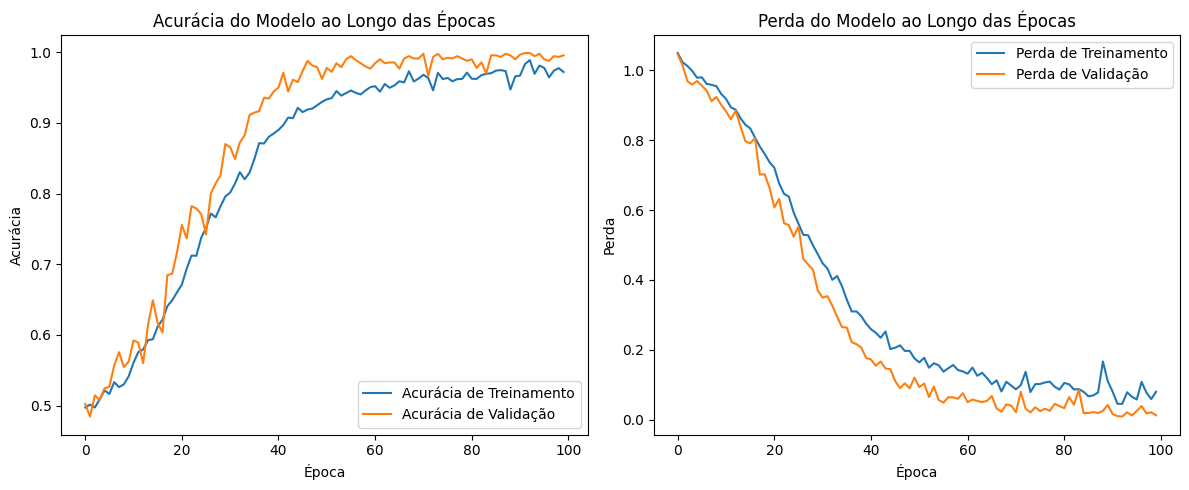

Modelo salvo como 'eeg_spectrogram_cnn_model_npy_200ms.keras'


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt # Importar matplotlib para as plotagens

# sample_spec = np.load('unified_spectrograms_200ms/rest/S001_R04_epoch_1_C3.npy') # Ajuste o caminho
# print(sample_spec.shape) # Por exemplo, (33, 81)
IMG_HEIGHT = 33 # Número de bins de frequência (rows de Zxx)
IMG_WIDTH = 81 # Número de bins de tempo (columns de Zxx)
NUM_CLASSES = 3 # 'rest', 'left', 'right'
BATCH_SIZE = 16
EPOCHS = 100

# Mapeamento de rótulos para inteiros
label_map = {'rest': 0, 'left': 1, 'right': 2}

# --- Função para carregar e pré-processar um único espectrograma (.npy) ---
def load_spectrogram_data(filepath_c3, filepath_c4, label):
    # Carrega os arrays NumPy
    spectrogram_c3 = np.load(filepath_c3.numpy()).astype(np.float32) # .numpy() para converter tf.Tensor para string
    spectrogram_c4 = np.load(filepath_c4.numpy()).astype(np.float32) # .numpy() para converter tf.Tensor para string

    # Normalização Min-Max: Importante!
    # Normalize cada espectrograma individualmente para o range [0, 1].
    # Adicionar 1e-8 ao denominador para evitar divisão por zero em casos de array constante.
    min_c3, max_c3 = np.min(spectrogram_c3), np.max(spectrogram_c3)
    spectrogram_c3 = (spectrogram_c3 - min_c3) / (max_c3 - min_c3 + 1e-8) if (max_c3 - min_c3) > 1e-8 else spectrogram_c3

    min_c4, max_c4 = np.min(spectrogram_c4), np.max(spectrogram_c4)
    spectrogram_c4 = (spectrogram_c4 - min_c4) / (max_c4 - min_c4 + 1e-8) if (max_c4 - min_c4) > 1e-8 else spectrogram_c4

    # Adiciona a dimensão do canal e concatena C3 e C4
    # Resulta em um array de shape (IMG_HEIGHT, IMG_WIDTH, 2)
    combined_spectrogram = np.stack([spectrogram_c3, spectrogram_c4], axis=-1)
    
    return combined_spectrogram, label

# --- Criar o dataset (AJUSTADO PARA A NOVA ESTRUTURA UNIFICADA) ---
def create_dataset_from_directories_npy(data_root_dir):
    all_filepaths_c3 = []
    all_filepaths_c4 = []
    all_labels = []

    print(f"Tentando ler do diretório raiz: {data_root_dir}")
    if not os.path.exists(data_root_dir):
        print(f"Erro: O diretório raiz dos dados não existe: {data_root_dir}")
        return None, None
            
    # Iterar diretamente sobre as subpastas de classes (left, right, rest)
    for class_name in label_map.keys():
        class_dir = os.path.join(data_root_dir, class_name)
        print(f"  Verificando diretório da classe: {class_dir}")
        if not os.path.exists(class_dir):
            print(f"  Aviso: O diretório da classe '{class_name}' não existe em {data_root_dir}. Pulando.")
            continue 

        # Iterar sobre os arquivos .npy de espectrograma dentro da pasta da classe
        for img_filename in os.listdir(class_dir):
            if img_filename.endswith('_C3.npy'):
                filepath_c3 = os.path.join(class_dir, img_filename)
                filepath_c4 = filepath_c3.replace('_C3.npy', '_C4.npy')
                
                if os.path.exists(filepath_c4): # Verifica se o C4 correspondente existe
                    all_filepaths_c3.append(filepath_c3)
                    all_filepaths_c4.append(filepath_c4)
                    all_labels.append(label_map[class_name])
                    # print(f"    Encontrado par: {filepath_c3} e {filepath_c4}") # Descomente para mais detalhes
                else:
                    print(f"    Aviso: Arquivo C4 correspondente para {filepath_c3} não encontrado. Pulando este par.")
    
    print(f"Total de arquivos C3 encontrados: {len(all_filepaths_c3)}")
    print(f"Total de arquivos C4 encontrados: {len(all_filepaths_c4)}")
    print(f"Total de rótulos encontrados: {len(all_labels)}")

    # Verificar se há dados para criar o dataset
    if len(all_filepaths_c3) == 0:
        print("Erro: Nenhum par de espectrogramas C3/C4 encontrado. O dataset está vazio.")
        return None, None

    # Converte para tensores TensorFlow
    filepaths_c3_tensor = tf.constant(all_filepaths_c3, dtype=tf.string) # Use dtype=tf.string
    filepaths_c4_tensor = tf.constant(all_filepaths_c4, dtype=tf.string) # Use dtype=tf.string
    labels_tensor = tf.constant(all_labels, dtype=tf.int32)

    # Cria o dataset TensorFlow
    # Usa tf.py_function para envolver a função NumPy pura
    dataset = tf.data.Dataset.from_tensor_slices(((filepaths_c3_tensor, filepaths_c4_tensor), labels_tensor))
    dataset = dataset.map(lambda x, y: tf.py_function(load_spectrogram_data, [x[0], x[1], y], (tf.float32, tf.int32)),
                          num_parallel_calls=tf.data.AUTOTUNE)
    
    # Define as formas dos tensores de saída da função tf.py_function
    # Isso é CRÍTICO para que o modelo saiba a forma dos inputs
    dataset = dataset.map(lambda spec, label: (tf.ensure_shape(spec, (IMG_HEIGHT, IMG_WIDTH, 2)), tf.ensure_shape(label, ())),
                          num_parallel_calls=tf.data.AUTOTUNE)

    # Divide em conjuntos de treinamento e validação (80/20)
    dataset_size = len(all_filepaths_c3) # Use o número de arquivos encontrados para o tamanho
    if dataset_size == 0: # Redundância, mas garante
        print("Erro: Dataset vazio após coleta de arquivos. Não há dados para treinamento/validação.")
        return None, None
        
    train_size = int(0.8 * dataset_size)

    dataset = dataset.shuffle(buffer_size=dataset_size) # Embaralha o dataset completo
    train_ds = dataset.take(train_size)
    val_ds = dataset.skip(train_size)

    # Otimizações para desempenho
    train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds

# --- Definição do Modelo CNN (ajustado para 2 canais) ---
def create_cnn_model_npy(input_shape=(IMG_HEIGHT, IMG_WIDTH, 2), num_classes=NUM_CLASSES): # input_shape agora tem 2 canais
    model = models.Sequential()

    # Camada Convolucional 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    # Camada Convolucional 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Camada Convolucional 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Achatar a saída das camadas convolucionais
    model.add(layers.Flatten())

    # Camadas Densas (Fully Connected)
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5)) # Dropout para evitar overfitting
    model.add(layers.Dense(num_classes, activation='softmax')) # Saída para classificação multiclasse

    # Compilar o modelo
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy', # Usar para labels inteiras
                  metrics=['accuracy'])
    
    return model

# --- Treinamento ---
if __name__ == '__main__':
    # Você pode iterar sobre window_durations_ms aqui se quiser treinar um modelo para cada
    # tamanho de janela, ou escolher um específico.
    
    # Exemplo: Treinando com os espectrogramas de 200ms
    # IMPORTANTE: Escolha AQUI a duração da janela que você deseja treinar!
    current_window_ms = 200 # <-- AJUSTE ISSO para 50, 100, 200, 400, 600, 800, ou 1000
    
    # O diretório raiz dos dados será o 'unified_spectrograms_XXXms' correspondente
    DATA_ROOT_DIR = f'unified_spectrograms_{current_window_ms}ms' 

    print(f"Assumindo IMG_HEIGHT={IMG_HEIGHT} e IMG_WIDTH={IMG_WIDTH}. Verifique se isso está correto.")
    
    print(f"\n--- Treinando o modelo para dados numéricos em {DATA_ROOT_DIR} ---")
    train_dataset, val_dataset = create_dataset_from_directories_npy(DATA_ROOT_DIR)

    if train_dataset is None: # Se o dataset foi None, houve um erro ou estava vazio
        print(f"Não foi possível carregar dados de treinamento de {DATA_ROOT_DIR}. Treinamento abortado.")
    elif tf.data.experimental.cardinality(train_dataset).numpy() == 0:
        print(f"Dataset de treinamento vazio em {DATA_ROOT_DIR}. Treinamento abortado.")
    else:
        model = create_cnn_model_npy()
        model.summary()

        history = model.fit(train_dataset,
                            epochs=EPOCHS,
                            validation_data=val_dataset)

        # --- Avaliação e Visualização dos Resultados do Treinamento ---
        print("\n--- Avaliação Final do Modelo ---")
        loss, accuracy = model.evaluate(val_dataset)
        print(f"Acurácia no conjunto de validação: {accuracy*100:.2f}%")

        # Plotar histórico de treinamento
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Acurácia de Treinamento')
        plt.plot(history.history['val_accuracy'], label='Acurácia de Validação')
        plt.xlabel('Época')
        plt.ylabel('Acurácia')
        plt.legend()
        plt.title('Acurácia do Modelo ao Longo das Épocas')

        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Perda de Treinamento')
        plt.plot(history.history['val_loss'], label='Perda de Validação')
        plt.xlabel('Época')
        plt.ylabel('Perda')
        plt.legend()
        plt.title('Perda do Modelo ao Longo das Épocas')
        plt.tight_layout()
        plt.show()

        # Opcional: Salvar o modelo treinado
        model.save(f'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras')
        print(f"Modelo salvo como 'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras'")

In [1]:
import tensorflow as tf

# Define the filename you used for saving
current_window_ms = 200 # Example value, use the actual value you used for saving
model_filename = f'eeg_spectrogram_cnn_model_npy_{current_window_ms}ms.keras'

# Load the model
loaded_model = tf.keras.models.load_model(model_filename)

# If you used custom layers, loss functions, or metrics, you might need to
# pass them to `custom_objects` when loading. For example:
# from your_module import CustomLayer, custom_loss_function
# loaded_model = tf.keras.models.load_model(model_filename,
#                                           custom_objects={'CustomLayer': CustomLayer,
#                                                           'custom_loss_function': custom_loss_function})

In [2]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 31, 79, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,066,859 (4.07 MB)

 Trainable params: 355,619 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 711,240 (2.71 MB)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# --- Funções de Processamento de Dados (Mantidas) ---

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of dictionaries, each containing (f, t, Zxx) for an epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            # print(f"        Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Ensure epoch is long enough for the STFT window
        if len(epoch) < nperseg:
            # print(f"        Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# --- Configurações Globais ---

# Pasta raiz contendo todas as subpastas de sujeitos (S001, S002, ...)
# Exemplo: Se seus arquivos estão em 'seu_projeto/data/phisionet_data/S001/'
# E o script está em 'seu_projeto/'
pasta_raiz_sujeitos = Path('data/phisionet_data') # <-- AJUSTE ISSO PARA O SEU CAMINHO RAIZ DOS SUJEITOS

# Define o range de sujeitos para o DATASET DE VALIDAÇÃO
# *** CRUCIAL: Certifique-se de que este range NÃO SE SOBREPONHA com o range usado para o treinamento! ***
start_subject_val = 55 # Por exemplo, de S040
end_subject_val = 80   # até S060

registros = ['R04', 'R08', 'R12'] # Arquivos EDF a serem processados por sujeito
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Mapeamento para nomes de pastas em minúsculas
epoch_duration_sec = 4 # Duração de cada época em segundos (tmax - tmin)

# Definir a taxa de amostragem globalmente (ASSUMIR UM VALOR CONSISTENTE OU LER DO PRIMEIRO ARQUIVO)
fs = 160 # Hz - Ajuste para a taxa de amostragem real dos seus dados (deve ser a mesma do treinamento)

# Definir as durações de janela da STFT a serem geradas (deve ser as mesmas do treinamento)
#window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]
window_durations_ms = [200]

print(f"Iniciando a geração de spectrograms para VALIDAÇÃO para sujeitos S{start_subject_val:03d} a S{end_subject_val:03d}")
print(f"e para as janelas: {window_durations_ms}ms")

# --- Loop Principal para Processamento (Aninhado) ---

# Loop externo: sobre cada duração de janela da STFT
for current_window_ms in window_durations_ms:
    current_window_s = current_window_ms / 1000.0
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * current_window_s)
    noverlap = int(nperseg * 0.75) # 75% de sobreposição para boa resolução temporal
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1 e noverlap < nperseg
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)
    if nperseg == 1:
        noverlap = 0

    print(f"\n--- Processando (VAL) com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    # Diretório de saída final para o dataset de VALIDAÇÃO unificado para esta janela específica
    base_output_data_dir = f"validation_unified_spectrograms_{current_window_ms}ms"
    
    # Crie as pastas de classe dentro do diretório de saída para esta janela de validação
    for class_folder_name in event_dict.values():
        os.makedirs(os.path.join(base_output_data_dir, class_folder_name), exist_ok=True)
    print(f"Diretório de saída para o dataset de VALIDAÇÃO: {base_output_data_dir}")

    # Loop intermediário: sobre cada sujeito no range de VALIDAÇÃO especificado
    for subject_num in range(start_subject_val, end_subject_val + 1):
        subject_id = f'S{subject_num:03d}' # Formata para S001, S002, etc.
        subject_folder_path = pasta_raiz_sujeitos / subject_id

        if not subject_folder_path.is_dir():
            print(f"  Pasta do sujeito {subject_id} não encontrada em {pasta_raiz_sujeitos}. Pulando.")
            continue

        print(f"  Processando Sujeito (VAL): {subject_id}")

        # Loop interno: sobre cada arquivo EDF (R04, R08, R12) dentro do sujeito
        for registro in registros:
            # Encontrar arquivo .edf correspondente
            edf_file = next(subject_folder_path.glob(f'*{registro}.edf'), None)
            if not edf_file:
                print(f"    Arquivo {registro}.edf não encontrado em {subject_folder_path}. Pulando.")
                continue

            # print(f"      Processando arquivo: {edf_file.name}") # Descomente para mais detalhes
            
            # Carregar dados EDF usando EdfReader
            reader = EdfReader(str(edf_file))
            
            # Obter informações dos sinais e taxa de amostragem
            # Se sua taxa de amostragem varia por arquivo, DESCOMENTE A LINHA ABAIXO
            # fs_current_file = reader.getSampleFrequency(0)
            # E substitua 'fs' por 'fs_current_file' nas chamadas de função e nos cálculos nperseg/noverlap
            
            n_channels = reader.signals_in_file
            signal_labels = reader.getSignalLabels()
            signals_data = np.array([reader.readSignal(c) for c in range(n_channels)])
            
            # Obter canais C3 e C4
            try:
                c3_idx = signal_labels.index('C3..')
                c4_idx = signal_labels.index('C4..')
            except ValueError:
                print(f"        Canais 'C3..' ou 'C4..' não encontrados em {edf_file.name}. Pulando este arquivo.")
                reader.close()
                continue

            c3_signal = signals_data[c3_idx, :]
            c4_signal = signals_data[c4_idx, :]
            
            # Ler anotações diretamente do arquivo EDF
            annotations_onset, annotations_duration, annotations_description = reader.readAnnotations()
            reader.close() # Fechar o reader após ler tudo

            # Converter anotações para formato de eventos (amostras em vez de segundos)
            events = []
            for onset, duration, description in zip(annotations_onset, annotations_duration, annotations_description):
                events.append([int(onset * fs), 0, description])
            
            # Aplicar filtros
            c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 50, fs)
            c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 50, fs)
            
            # Processar condições (T0, T1, T2)
            conditions = ['T0', 'T1', 'T2']
            all_epoch_stfts_for_file = {} # Armazena STFTs para o arquivo atual

            for cond_key in conditions:
                # print(f"        Calculando STFT para {event_dict[cond_key].capitalize()}...")
                c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
                
                all_epoch_stfts_for_file[cond_key] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

            # Saving Spectrograms to the unified VALIDAÇÃO structure
            for cond_key in conditions:
                c3_data = all_epoch_stfts_for_file[cond_key]['C3']
                c4_data = all_epoch_stfts_for_file[cond_key]['C4']

                # Diretório de saída específico para esta classe (ex: 'validation_unified_spectrograms_200ms/rest')
                class_output_dir = os.path.join(base_output_data_dir, event_dict[cond_key])
                # print(f"        Salvando espectrogramas em: {class_output_dir}") # Descomente para mais detalhes

                # Iterar sobre cada época individual para salvar
                for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
                    epoch_idx = c3_data[j]['epoch_idx']
                    # f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
                    # f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['magnitude']
                    
                    # Apenas pegar os dados de magnitude para salvar
                    Zxx_c3 = c3_data[j]['magnitude']
                    Zxx_c4 = c4_data[j]['magnitude']


                    # Nome do arquivo agora inclui Sujeito_Registro_Época_Canal
                    base_filename = f"{subject_id}_{edf_file.stem.replace('.', '_')}_epoch_{epoch_idx+1}" # Ex: S040_R04_epoch_1

                    # Caminho completo para salvar o arquivo .npy C3
                    npy_c3_path = os.path.join(class_output_dir, f"{base_filename}_C3.npy")
                    np.save(npy_c3_path, Zxx_c3)

                    # Caminho completo para salvar o arquivo .npy C4
                    npy_c4_path = os.path.join(class_output_dir, f"{base_filename}_C4.npy")
                    np.save(npy_c4_path, Zxx_c4)

                    # (Opcional: Manter o salvamento do PNG se desejar visualizar os espectrogramas)
                    # Recomendo FORTEMENTE DESABILITAR para grandes datasets.
                    # As variáveis f_c3, t_c3, f_c4, t_c4 teriam que ser descomentadas acima para isso.
                    # fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
                    # im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
                    # fig.colorbar(im1, ax=axes[0], label='Magnitude')
                    # axes[0].set_title(f'{event_dict[cond_key].capitalize()} - {subject_id}_{edf_file.stem} - Época {epoch_idx+1} - C3')
                    # axes[0].set_ylabel('Frequência [Hz]')
                    # axes[0].set_xlabel('Tempo [s]')
                    # axes[0].set_ylim([8, 30])
                    # im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
                    # fig.colorbar(im2, ax=axes[1], label='Magnitude')
                    # axes[1].set_title(f'{event_dict[cond_key].capitalize()} - {subject_id}_{edf_file.stem} - Época {epoch_idx+1} - C4')
                    # axes[1].set_xlabel('Tempo [s]')
                    # axes[1].set_ylim([8, 30])
                    # plt.tight_layout()
                    # png_path = os.path.join(class_output_dir, f"{base_filename}.png")
                    # plt.savefig(png_path)
                    # plt.close(fig)

print(f"\nProcessamento de validação concluído. Todos os espectrogramas foram salvos na estrutura unificada em seus respectivos diretórios de janela.")

Iniciando a geração de spectrograms para VALIDAÇÃO para sujeitos S055 a S080
e para as janelas: [200]ms

--- Processando (VAL) com Janela de 200ms (nperseg=32, noverlap=24) ---
Diretório de saída para o dataset de VALIDAÇÃO: validation_unified_spectrograms_200ms
  Processando Sujeito (VAL): S055
  Processando Sujeito (VAL): S056
  Processando Sujeito (VAL): S057
  Processando Sujeito (VAL): S058
  Processando Sujeito (VAL): S059
  Processando Sujeito (VAL): S060
  Processando Sujeito (VAL): S061
  Processando Sujeito (VAL): S062
  Processando Sujeito (VAL): S063
  Processando Sujeito (VAL): S064
  Processando Sujeito (VAL): S065
  Processando Sujeito (VAL): S066
  Processando Sujeito (VAL): S067
  Processando Sujeito (VAL): S068
  Processando Sujeito (VAL): S069
  Processando Sujeito (VAL): S070
  Processando Sujeito (VAL): S071
  Processando Sujeito (VAL): S072
  Processando Sujeito (VAL): S073
  Processando Sujeito (VAL): S074
  Processando Sujeito (VAL): S075
  Processando Sujeito (


--- Avaliando o modelo para a janela de 200ms ---
Carregando o modelo de: eeg_spectrogram_cnn_model_npy_200ms.keras


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 31, 79, 32)     │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,066,859 (4.07 MB)

 Trainable params: 355,619 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 711,240 (2.71 MB)

Tentando ler do diretório raiz: validation_unified_spectrograms_200ms
  Verificando diretório da classe: validation_unified_spectrograms_200ms\rest
  Verificando diretório da classe: validation_unified_spectrograms_200ms\left
  Verificando diretório da classe: validation_unified_spectrograms_200ms\right
Total de arquivos C3 encontrados: 2340
Total de arquivos C4 encontrados: 2340
Total de rótulos encontrados: 2340

--- Iniciando a avaliação no dataset de validação ---

Resultados da Avaliação (200ms):
  Perda no conjunto de validação: 7.0085
  Acurácia no conjunto de validação: 45.43%

--- Coletando previsões para análise detalhada ---

--- Gerando Matriz de Confusão ---
[[696 255 219]
 [245 192 154]
 [243 161 175]]


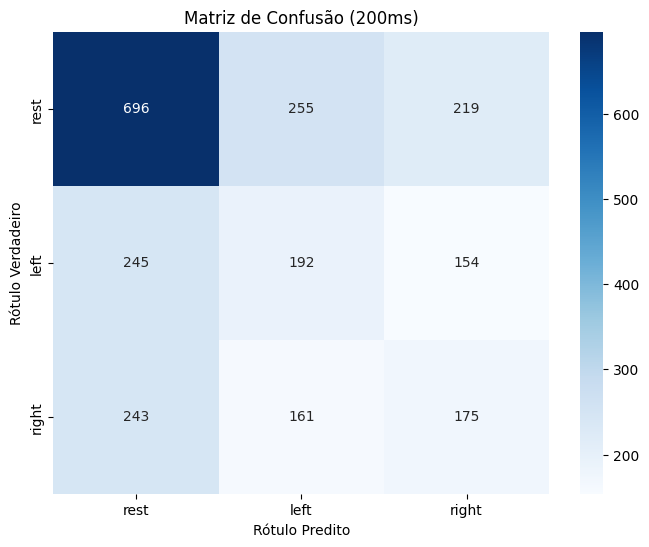


--- Relatório de Classificação ---
              precision    recall  f1-score   support

        rest       0.59      0.59      0.59      1170
        left       0.32      0.32      0.32       591
       right       0.32      0.30      0.31       579

    accuracy                           0.45      2340
   macro avg       0.41      0.41      0.41      2340
weighted avg       0.45      0.45      0.45      2340


--- Visualizando alguns espectrogramas com previsões (C3 e C4) ---
Tentando ler do diretório raiz: validation_unified_spectrograms_200ms
  Verificando diretório da classe: validation_unified_spectrograms_200ms\rest
  Verificando diretório da classe: validation_unified_spectrograms_200ms\left
  Verificando diretório da classe: validation_unified_spectrograms_200ms\right
Total de arquivos C3 encontrados: 2340
Total de arquivos C4 encontrados: 2340
Total de rótulos encontrados: 2340


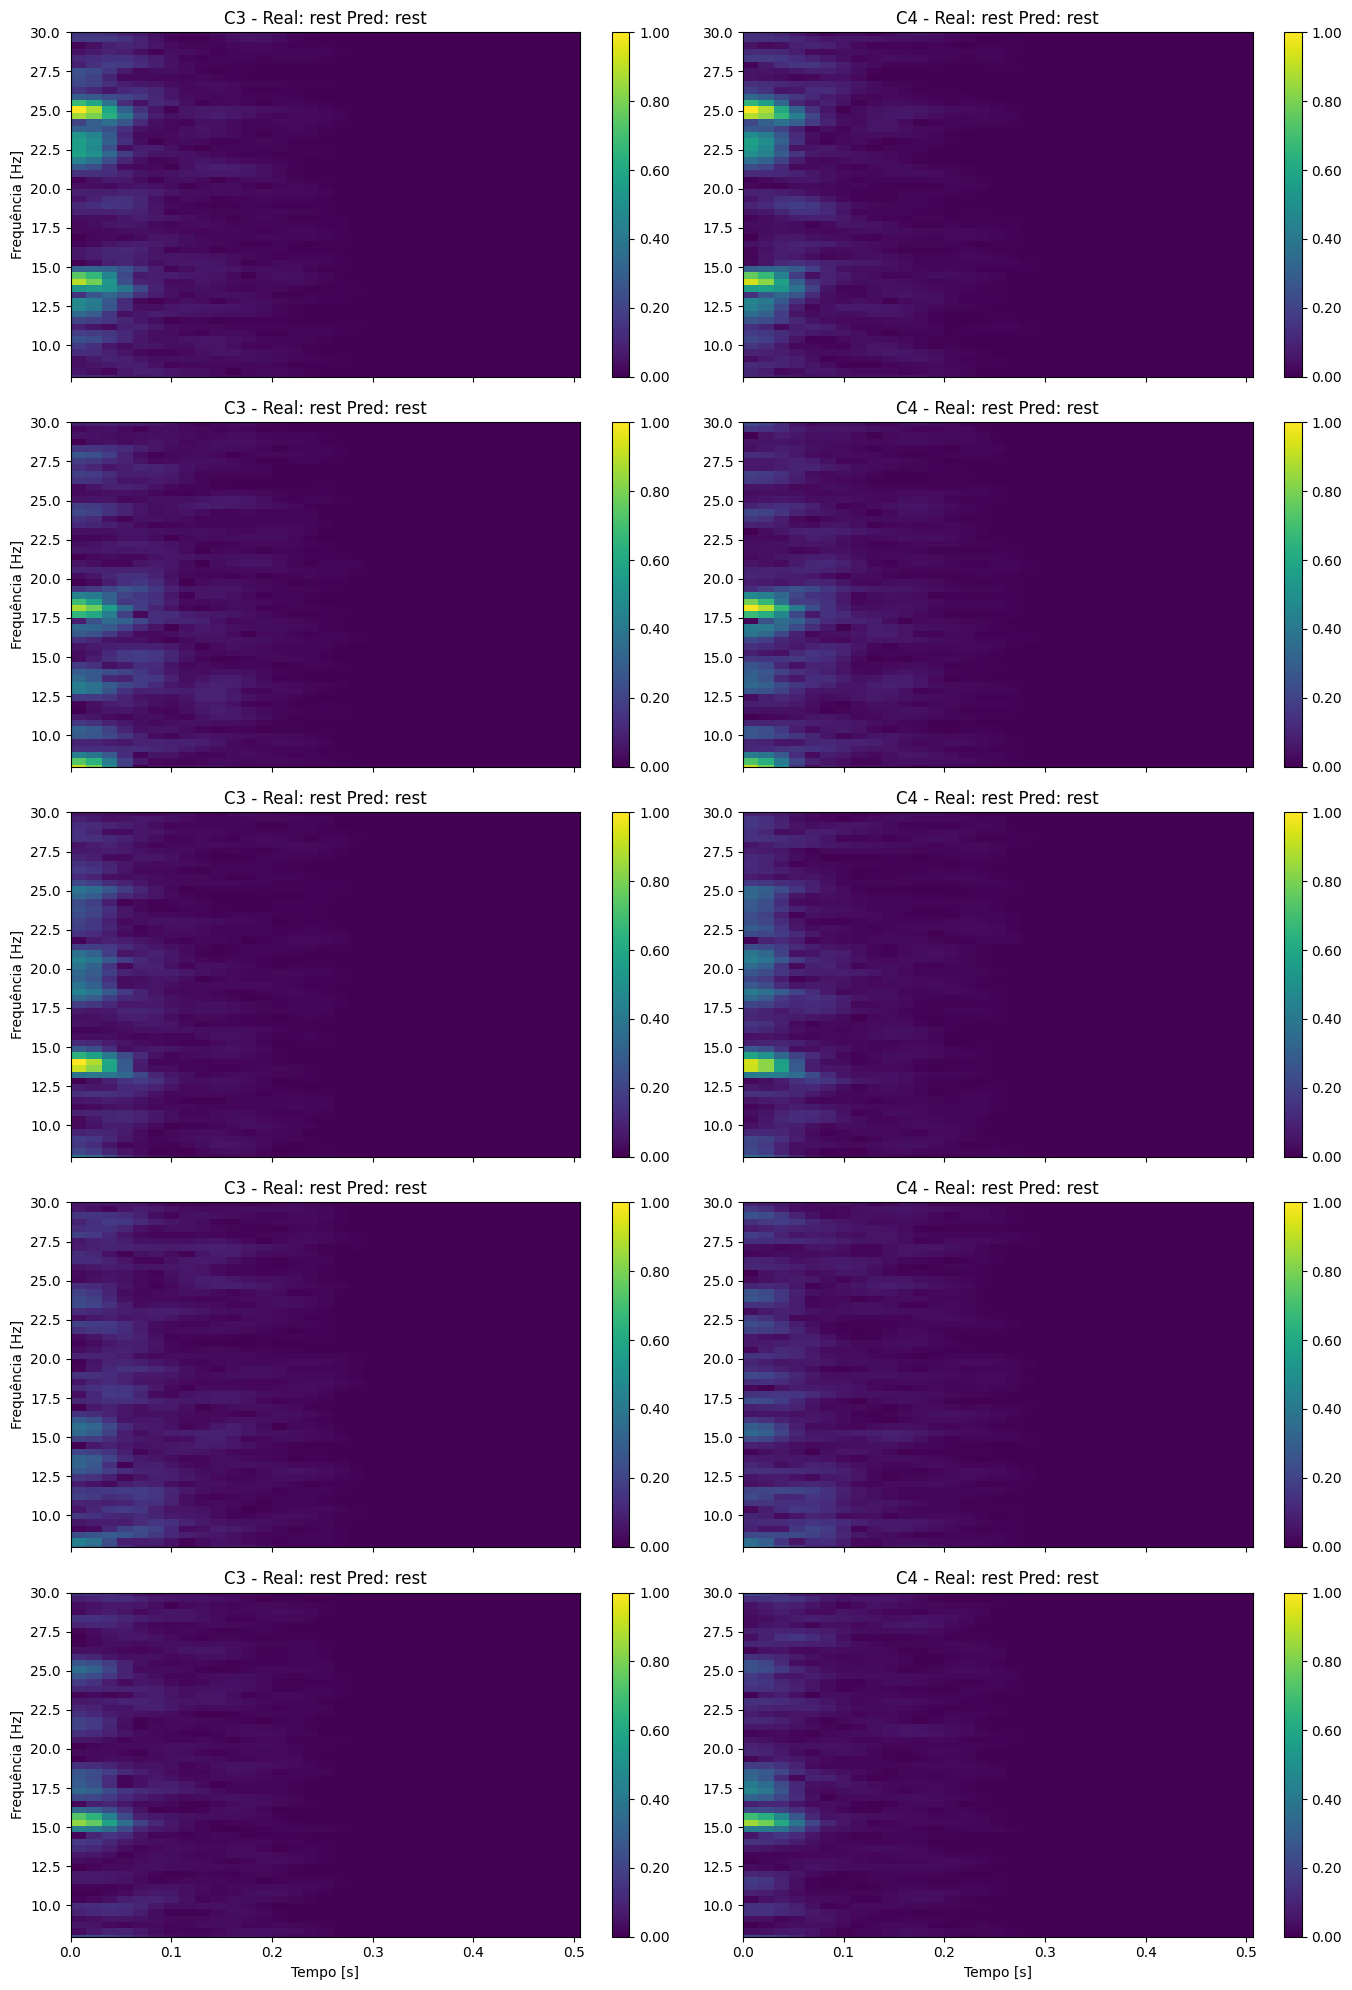

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt # Importar matplotlib para as plotagens

# Importar ferramentas de avaliação do scikit-learn
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns # Para uma matriz de confusão mais bonita (opcional)

# --- Parâmetros de Configuração (DEVE SER OS MESMOS USADOS NO TREINAMENTO E GERAÇÃO DE DADOS) ---
# Estas dimensões devem corresponder EXATAMENTE à saída da sua STFT.
# Verifique com um arquivo .npy: np.load('caminho/do/seu/arquivo.npy').shape
IMG_HEIGHT = 33 # Número de bins de frequência (rows de Zxx)
IMG_WIDTH = 81 # Número de bins de tempo (columns de Zxx)
NUM_CLASSES = 3 # 'rest', 'left', 'right'
BATCH_SIZE = 16 # Use o mesmo batch size do treinamento ou um similar
EPOCHS = 10 # Este é apenas para referência, não será usado na avaliação
fs = 160

# Mapeamento de rótulos para inteiros (deve ser o mesmo do treinamento)
label_map = {'rest': 0, 'left': 1, 'right': 2}
class_names = ['rest', 'left', 'right'] # Para visualização e relatório, na ordem dos seus rótulos numéricos

# --- Função para carregar e pré-processar um único espectrograma (.npy) ---
# Esta função deve ser IDÊNTICA à usada durante o treinamento do modelo.
def load_spectrogram_data(filepath_c3, filepath_c4, label):
    spectrogram_c3 = np.load(filepath_c3.numpy()).astype(np.float32)
    spectrogram_c4 = np.load(filepath_c4.numpy()).astype(np.float32)

    # Normalização Min-Max: Importante! (Deve ser a mesma do treinamento)
    min_c3, max_c3 = np.min(spectrogram_c3), np.max(spectrogram_c3)
    spectrogram_c3 = (spectrogram_c3 - min_c3) / (max_c3 - min_c3 + 1e-8) if (max_c3 - min_c3) > 1e-8 else spectrogram_c3

    min_c4, max_c4 = np.min(spectrogram_c4), np.max(spectrogram_c4)
    spectrogram_c4 = (spectrogram_c4 - min_c4) / (max_c4 - min_c4 + 1e-8) if (max_c4 - min_c4) > 1e-8 else spectrogram_c4

    combined_spectrogram = np.stack([spectrogram_c3, spectrogram_c4], axis=-1)
    
    return combined_spectrogram, label

# --- Função para Criar o Dataset (IDÊNTICA À USADA NO TREINAMENTO, MAS APONTA PARA DADOS DE VALIDAÇÃO) ---
def create_dataset_from_directories_npy(data_root_dir):
    all_filepaths_c3 = []
    all_filepaths_c4 = []
    all_labels = []

    print(f"Tentando ler do diretório raiz: {data_root_dir}")
    if not os.path.exists(data_root_dir):
        print(f"Erro: O diretório raiz dos dados não existe: {data_root_dir}")
        return None, None
            
    for class_name in label_map.keys():
        class_dir = os.path.join(data_root_dir, class_name)
        print(f"  Verificando diretório da classe: {class_dir}")
        if not os.path.exists(class_dir):
            print(f"  Aviso: O diretório da classe '{class_name}' não existe em {data_root_dir}. Pulando.")
            continue 

        for img_filename in os.listdir(class_dir):
            if img_filename.endswith('_C3.npy'):
                filepath_c3 = os.path.join(class_dir, img_filename)
                filepath_c4 = filepath_c3.replace('_C3.npy', '_C4.npy')
                
                if os.path.exists(filepath_c4):
                    all_filepaths_c3.append(filepath_c3)
                    all_filepaths_c4.append(filepath_c4)
                    all_labels.append(label_map[class_name])
                else:
                    print(f"    Aviso: Arquivo C4 correspondente para {filepath_c3} não encontrado. Pulando este par.")
    
    print(f"Total de arquivos C3 encontrados: {len(all_filepaths_c3)}")
    print(f"Total de arquivos C4 encontrados: {len(all_filepaths_c4)}")
    print(f"Total de rótulos encontrados: {len(all_labels)}")

    if len(all_filepaths_c3) == 0:
        print("Erro: Nenhum par de espectrogramas C3/C4 encontrado. O dataset está vazio.")
        return None, None

    filepaths_c3_tensor = tf.constant(all_filepaths_c3, dtype=tf.string)
    filepaths_c4_tensor = tf.constant(all_filepaths_c4, dtype=tf.string)
    labels_tensor = tf.constant(all_labels, dtype=tf.int32)

    dataset = tf.data.Dataset.from_tensor_slices(((filepaths_c3_tensor, filepaths_c4_tensor), labels_tensor))
    dataset = dataset.map(lambda x, y: tf.py_function(load_spectrogram_data, [x[0], x[1], y], (tf.float32, tf.int32)),
                          num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.map(lambda spec, label: (tf.ensure_shape(spec, (IMG_HEIGHT, IMG_WIDTH, 2)), tf.ensure_shape(label, ())),
                          num_parallel_calls=tf.data.AUTOTUNE)

    # Não precisamos dividir em treino/validação novamente, pois este é o dataset de validação completo
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

# --- Função Principal para Avaliação ---
if __name__ == '__main__':
    # Escolha a duração da janela do modelo que você deseja carregar
    # e do dataset de validação que você deseja usar.
    # DEVE SER A MESMA! Ex: se o modelo foi treinado com 200ms, use 200 aqui.
    selected_window_ms = 200 # <-- AJUSTE ISSO para a janela do seu modelo/dados de validação
    
    # Caminho para o modelo treinado
    model_path = f'eeg_spectrogram_cnn_model_npy_{selected_window_ms}ms.keras'
    
    # Caminho para o diretório raiz do dataset de validação
    validation_data_root_dir = f'validation_unified_spectrograms_{selected_window_ms}ms'

    print(f"\n--- Avaliando o modelo para a janela de {selected_window_ms}ms ---")

    # 1. Carregar o modelo treinado
    if not os.path.exists(model_path):
        print(f"Erro: Modelo treinado não encontrado em: {model_path}. Certifique-se de que o modelo foi salvo após o treinamento.")
    else:
        print(f"Carregando o modelo de: {model_path}")
        model = models.load_model(model_path)
        model.summary()

        # 2. Carregar o dataset de validação
        val_dataset = create_dataset_from_directories_npy(validation_data_root_dir)

        if val_dataset is None:
            print(f"Não foi possível carregar o dataset de validação de {validation_data_root_dir}. Avaliação abortada.")
        elif tf.data.experimental.cardinality(val_dataset).numpy() == 0:
            print(f"Dataset de validação vazio em {validation_data_root_dir}. Avaliação abortada.")
        else:
            # 3. Avaliar o modelo
            print("\n--- Iniciando a avaliação no dataset de validação ---")
            loss, accuracy = model.evaluate(val_dataset, verbose=0) # verbose=0 para não imprimir progresso aqui
            print(f"\nResultados da Avaliação ({selected_window_ms}ms):")
            print(f"  Perda no conjunto de validação: {loss:.4f}")
            print(f"  Acurácia no conjunto de validação: {accuracy*100:.2f}%")

            # 4. Fazer Previsões e Coletar Rótulos
            print("\n--- Coletando previsões para análise detalhada ---")
            all_predictions = []
            all_true_labels = []

            for spectrograms_batch, labels_batch in val_dataset:
                # Fazer previsão no batch atual
                predictions_batch = model.predict(spectrograms_batch, verbose=0)
                
                # Converter probabilidades para classes preditas (índices)
                predicted_classes_batch = np.argmax(predictions_batch, axis=1)
                
                # Armazenar para análise posterior
                all_predictions.extend(predicted_classes_batch)
                all_true_labels.extend(labels_batch.numpy())
            
            # Converter listas para arrays numpy para sklearn
            all_predictions = np.array(all_predictions)
            all_true_labels = np.array(all_true_labels)

            # 5. Gerar e Plotar Matriz de Confusão
            print("\n--- Gerando Matriz de Confusão ---")
            cm = confusion_matrix(all_true_labels, all_predictions)
            print(cm)

            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=class_names, yticklabels=class_names)
            plt.title(f'Matriz de Confusão ({selected_window_ms}ms)')
            plt.xlabel('Rótulo Predito')
            plt.ylabel('Rótulo Verdadeiro')
            plt.show()

            # 6. Gerar Relatório de Classificação
            print("\n--- Relatório de Classificação ---")
            report = classification_report(all_true_labels, all_predictions, target_names=class_names, zero_division=0)
            print(report)

            # 7. Visualizar alguns Espectrogramas com Previsões
            print("\n--- Visualizando alguns espectrogramas com previsões (C3 e C4) ---")
            num_samples_to_plot = 5 # Quantos exemplos você quer visualizar
            
            # Reiniciar o dataset para pegar as primeiras amostras
            val_dataset_for_plot = create_dataset_from_directories_npy(validation_data_root_dir)
            
            # Plotar os primeiros N exemplos
            fig, axes = plt.subplots(num_samples_to_plot, 2, figsize=(14, 4 * num_samples_to_plot), sharex=True)
            axes = axes.flatten() # Achata a matriz de subplots para facilitar a iteração

            sample_count = 0
            for spectrograms_batch, labels_batch in val_dataset_for_plot.take(num_samples_to_plot // BATCH_SIZE + 1): # Pega batches suficientes
                if sample_count >= num_samples_to_plot:
                    break
                
                predictions_batch = model.predict(spectrograms_batch, verbose=0)

                for i in range(min(BATCH_SIZE, num_samples_to_plot - sample_count)):
                    spec_c3 = spectrograms_batch[i,:,:,0].numpy().T # Transpor para visualização correta (tempo no eixo x, freq no y)
                    spec_c4 = spectrograms_batch[i,:,:,1].numpy().T # Transpor
                    
                    true_label_idx = labels_batch[i].numpy()
                    predicted_label_idx = np.argmax(predictions_batch[i])

                    # Plot C3
                    ax_c3 = axes[sample_count * 2]
                    im_c3 = ax_c3.imshow(spec_c3, aspect='auto', origin='lower', cmap='viridis', 
                                         extent=[0, IMG_WIDTH/fs, 0, IMG_HEIGHT]) # Ajuste o extent para tempo e frequência
                    ax_c3.set_title(f'C3 - Real: {class_names[true_label_idx]} Pred: {class_names[predicted_label_idx]}')
                    ax_c3.set_ylabel('Frequência [Hz]')
                    if sample_count == num_samples_to_plot - 1: # Apenas no último subplot da coluna
                        ax_c3.set_xlabel('Tempo [s]')
                    ax_c3.set_ylim([8, 30]) # Foco nas bandas relevantes
                    fig.colorbar(im_c3, ax=ax_c3, format='%.2f') # Adiciona barra de cores

                    # Plot C4
                    ax_c4 = axes[sample_count * 2 + 1]
                    im_c4 = ax_c4.imshow(spec_c4, aspect='auto', origin='lower', cmap='viridis', 
                                         extent=[0, IMG_WIDTH/fs, 0, IMG_HEIGHT]) # Ajuste o extent para tempo e frequência
                    ax_c4.set_title(f'C4 - Real: {class_names[true_label_idx]} Pred: {class_names[predicted_label_idx]}')
                    if sample_count == num_samples_to_plot - 1: # Apenas no último subplot da coluna
                        ax_c4.set_xlabel('Tempo [s]')
                    ax_c4.set_ylim([8, 30]) # Foco nas bandas relevantes
                    fig.colorbar(im_c4, ax=ax_c4, format='%.2f') # Adiciona barra de cores

                    sample_count += 1
                    if sample_count >= num_samples_to_plot:
                        break
            
            plt.tight_layout()
            plt.show()